In [1]:
## Analisi COVID-19 IN PYTHON
## 1) Importiamo e carichiamo il dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#URL dataset
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

In [4]:
## caricamento
df = pd.read_csv (url)

In [5]:
## visualizzazione prime righe
print (df.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

In [6]:
## dimensioni dataset
print ("Dimensioni datast:")
print (df .shape)

Dimensioni datast:
(429435, 67)


In [7]:
## informazioni generali e relativi metadati
print (df .info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [ ]:
## il dataset ci fa capire che al suo interno sono presenti sia variabili testuali che variabili numeriche.

In [8]:
## tipologia colonne
print (df .dtypes)

iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
population                                   int64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 67, dtype: object


In [9]:
#valori nulli
null_values = df.isnull () . sum ()
print (null_values.sort_values (ascending= False))

weekly_icu_admissions_per_million          418442
weekly_icu_admissions                      418442
excess_mortality_cumulative_per_million    416024
excess_mortality                           416024
excess_mortality_cumulative                416024
                                            ...  
total_deaths                                17631
population                                      0
date                                            0
location                                        0
iso_code                                        0
Length: 67, dtype: int64


In [ ]:
## Dal controllo dei valori nulli emerge che alcune variabili, come weekly_icu_admissions ed excess_mortality, presentano molti valori mancanti.
## le colonne fondamentali per l'identificazione delle osservazioni, come date, location, iso_code e popolazione, risultano invece complete.

In [25]:
## 2) Analisi per continente
## a) numero totale casi dall'inizio pandemia
## filtriamo il dataset escludendo le righe aggregate ( dove continente è nullo) 
df_continents = df.dropna (subset=["continent"])

In [26]:
## Total_cases è cumulativa:
## per evitare duplicazioni, prendiamo il valore massimo per ogni nazione 
total_cases_per_country = (df_continents.groupby(["continent", "location"])["total_cases"].max().reset_index())

In [27]:
## Somma dei casi per continente
cases_by_continents=(total_cases_per_country.groupby("continent") ["total_cases"].sum().reset_index())

In [28]:
print (continent_cases)

continent
Africa            13145380.0
Asia             301499099.0
Europe           252916868.0
North America    124492666.0
Oceania           15003352.0
South America     68809418.0
Name: total_cases, dtype: float64


In [ ]:
## commento sul risultato: L'Asia risulta il continente con il maggior numero dei casi cumulativi, seguita dall'Europa. 
## Oceania e Africa presentano invece valori inferiori.


In [24]:
## Calcolo totale mondiale
total_world_cases = cases_by_continents ["total_cases"].sum()

In [34]:
## 2b) percentuale rispetto al totale mondiale
cases_by_continents["percentage_of_world"]= (cases_by_continents ["total_cases"]/total_world_cases * 100).round(2)
print(cases_by_continents)

       continent  total_cases  percentage_of_world
0         Africa   13145540.0                 1.69
1           Asia  301532347.0                38.86
2         Europe  252916868.0                32.60
3  North America  124492666.0                16.04
4        Oceania   15003352.0                 1.93
5  South America   68809418.0                 8.87


In [36]:
print("--- Focus Italia 2022 ---")


--- Focus Italia 2022 ---


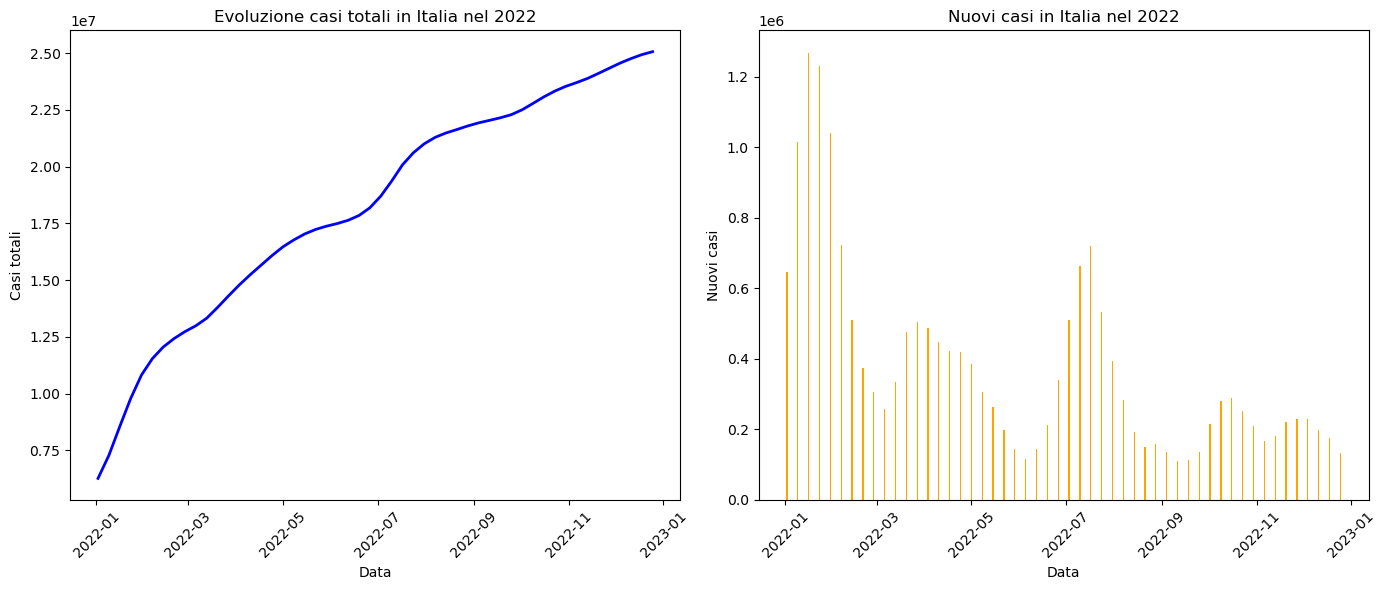

In [57]:

df['date'] = pd.to_datetime(df['date'])

df_italia_2022_filtered = df[
    (df['location'] == 'Italy') &
    (df['date'].dt.year == 2022) &
    (df['new_cases'].notna()) &
    (df['new_cases'] > 0)
].copy()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(df_italia_2022_filtered['date'],
    df_italia_2022_filtered['total_cases'],
    color='blue',
    lw=2)
plt.title("Evoluzione casi totali in Italia nel 2022")
plt.xlabel("Data")
plt.ylabel("Casi totali")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(df_italia_2022_filtered['date'],
    df_italia_2022_filtered['new_cases'],
    color='orange')
plt.title("Nuovi casi in Italia nel 2022")
plt.xlabel("Data")
plt.ylabel("Nuovi casi")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
## 4) Analisi terapie intensive Italia, Germania, Francia
## periodo: Maggio 2022- Aprile 2023

In [59]:
print("---Domanda 4: Terapie Intensive---")

---Domanda 4: Terapie Intensive---


             date location  icu_patients
131214 2022-05-01   France        1557.0
131215 2022-05-02   France        1511.0
131216 2022-05-03   France        1498.0
131217 2022-05-04   France        1465.0
131218 2022-05-05   France        1447.0


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24488\2451878585.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


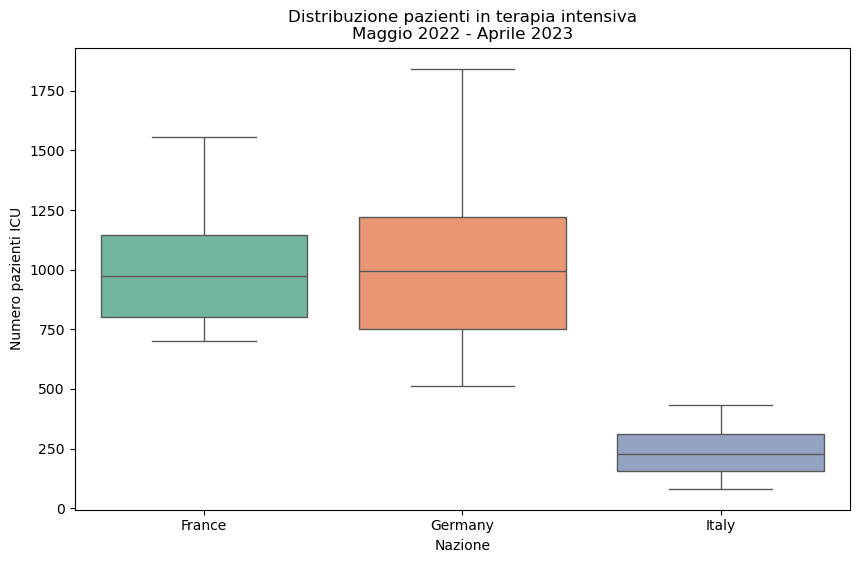

--- COMMENTO ICU ---
Il boxplot mostra differenze nella distribuzione dei pazienti in terapia intensiva tra Italia, Germania e Francia. La Germania presenta valori mediamente più elevati e una maggiore variabilità, probabilmente dovuta alla maggiore popolazione e capacità ospedaliera.


In [64]:
## Selezione nazioni
nazioni_icu = ['Italy', 'Germany', 'France']

##Filtro dati
df_icu = df[
    (df['location'].isin(nazioni_icu)) &
    (df['date'] >= '2022-05-01') &
    (df['date'] <= '2023-04-30')
].copy()

## Visualizzazione prime righe
print(df_icu[['date', 'location', 'icu_patients']].head())

## 4.a - BOXPLOT ICU PATIENTS


plt.figure(figsize=(10,6))

sns.boxplot(
    x='location',
    y='icu_patients',
    data=df_icu,
    palette='Set2'
)

plt.title(
    "Distribuzione pazienti in terapia intensiva\n"
    "Maggio 2022 - Aprile 2023"
)

plt.xlabel("Nazione")
plt.ylabel("Numero pazienti ICU")

plt.show()


## 4.b - COMMENTO


print("--- COMMENTO ICU ---")

commento_4 = (
    "Il boxplot mostra differenze nella distribuzione "
    "dei pazienti in terapia intensiva tra Italia, "
    "Germania e Francia. La Germania presenta valori "
    "mediamente più elevati e una maggiore variabilità, "
    "probabilmente dovuta alla maggiore popolazione "
    "e capacità ospedaliera."
)

print(commento_4)

In [72]:
print("---RICHIESTA 5: PAZIENTI OSPEDALIZZATI ---")

## Selezione nazioni
nazioni_hosp = ['Italy', 'Germany', 'France', 'Spain']

# Filtro anno 2021
df_hosp_2021 = df[
    (df['location'].isin(nazioni_hosp)) &
    (df['date'].dt.year == 2021)
].copy()

---RICHIESTA 5: PAZIENTI OSPEDALIZZATI ---


In [73]:
##5.a - SOMMA PAZIENTI OSPEDALIZZATI

somma_hosp = (
    df_hosp_2021
    .groupby('location')['hosp_patients']
    .sum()
    .reset_index())

print("--- SOMMA PAZIENTI OSPEDALIZZATI 2021 ---")
print(somma_hosp)

--- SOMMA PAZIENTI OSPEDALIZZATI 2021 ---
  location  hosp_patients
0   France      6008717.0
1  Germany            0.0
2    Italy      4419950.0
3    Spain      2411706.0


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24488\4233623703.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


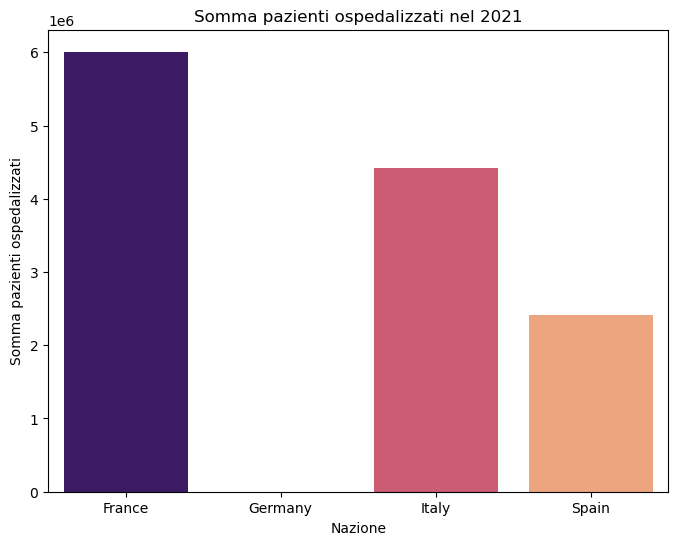

In [74]:
## GRAFICO
plt.figure(figsize=(8,6))

sns.barplot(
    data=somma_hosp,
    x='location',
    y='hosp_patients',
    palette='magma'
)

plt.title("Somma pazienti ospedalizzati nel 2021")

plt.xlabel("Nazione")
plt.ylabel("Somma pazienti ospedalizzati")

plt.show()

In [75]:
## 5.b - CONTROLLO VALORI NULLI
nulli_hosp = (
    df_hosp_2021
    .groupby('location')['hosp_patients']
    .apply(lambda x: x.isna().sum())
    .reset_index(name='Valori Nulli')
)

print("--- VALORI NULLI ---")
print(nulli_hosp)

--- VALORI NULLI ---
  location  Valori Nulli
0   France             0
1  Germany           365
2    Italy             0
3    Spain             0


In [76]:
## COMMENTO

print("--- COMMENTO DATI NULLI ---")

commento_5 = (
    "La presenza di valori nulli può influenzare "
    "le analisi statistiche e i calcoli cumulativi. "
    "Per gestire i dati mancanti si possono utilizzare "
    "tecniche di interpolazione temporale o medie mobili. "
    "La sostituzione con zero dovrebbe essere evitata "
    "se non coerente con il contesto reale dei dati.")

print(commento_5)

--- COMMENTO DATI NULLI ---
La presenza di valori nulli può influenzare le analisi statistiche e i calcoli cumulativi. Per gestire i dati mancanti si possono utilizzare tecniche di interpolazione temporale o medie mobili. La sostituzione con zero dovrebbe essere evitata se non coerente con il contesto reale dei dati.
